In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

%matplotlib inline

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Train images:", x_train.shape) 
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)    
print("Unique labels:", np.unique(y_train))

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


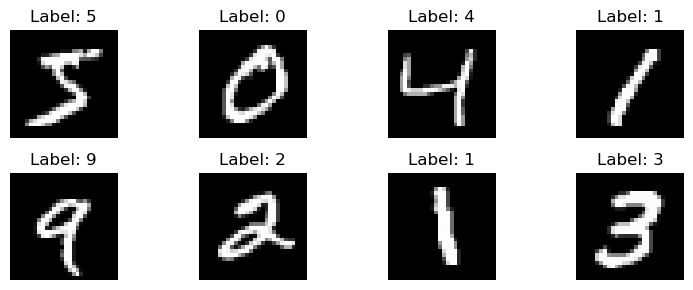

In [3]:
# Visualize first 8 training samples to understand the data
NUM_SAMPLES = 8
GRID_ROWS, GRID_COLS = 2, 4

plt.figure(figsize=(8, 3))
for i in range(NUM_SAMPLES):
    plt.subplot(GRID_ROWS, GRID_COLS, i+1)  
    plt.imshow(x_train[i], cmap='gray')     
    plt.title(f"Label: {y_train[i]}")       
    plt.axis('off')                          
plt.tight_layout()                           
plt.show()

In [4]:
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32)  / 255.0

x_train_flat = x_train.reshape(x_train.shape[0], -1)  
x_test_flat  = x_test.reshape(x_test.shape[0], -1)     

In [5]:
print(f"Flattened train shape: {x_train_flat.shape}")  # Should be (60000, 784)
print(f"Flattened test shape: {x_test_flat.shape}")    # Should be (10000, 784)

Flattened train shape: (60000, 784)
Flattened test shape: (10000, 784)


In [6]:
class NeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01, random_seed=42):
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.num_layers = len(layer_sizes) - 1
        np.random.seed(random_seed)
        self.weights = []
        self.biases = []
        self._initialize_weights()
        self.cache = {}